In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, 
                              confusion_matrix, roc_auc_score, classification_report)
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

os.makedirs('figures', exist_ok=True)

# Panel'i yükle
panel = pd.read_parquet('data/panel.parquet')
panel['year_month'] = pd.PeriodIndex(panel['year_month'], freq='M')
print(f"Panel: {panel.shape}")
print(panel.head())
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier


In [4]:
# Özellik grupları
WEATHER_FEATURES = ['sunshine_hours','daylight_hours','temperature_2m_mean',
                    'temperature_2m_max','temperature_2m_min',
                    'precipitation_sum','rain_sum','precipitation_hours']
CONTROL_FEATURES = ['unemployment_rate','inflation_yoy','covid_dummy',
                    'month_sin','month_cos']
TARGETS = ['CCI','retail_index']

# Türkiye enflasyonu çok yüksek — log transform
panel['inflation_log'] = np.log1p(panel['inflation_yoy'].clip(lower=0))

# Eksik değerleri ülke ortalamasıyla doldur (basit imputation)
for col in WEATHER_FEATURES + CONTROL_FEATURES + TARGETS:
    if col in panel.columns:
        panel[col] = panel.groupby('country')[col].transform(
            lambda x: x.fillna(x.mean()))

# Geriye kalan NaN satırlarını düşür (özellikle UK retail eksik)

print(f"NaN düşürmeden önce: {panel.shape}")
panel_clean = panel.dropna(subset=WEATHER_FEATURES + ['CCI'])
print(f"NaN düşürdükten sonra (CCI için): {panel_clean.shape}")

# Retail için ayrı bir alt-set (UK çoğunlukla NaN)
panel_retail = panel.dropna(subset=WEATHER_FEATURES + ['retail_index'])
print(f"Retail için: {panel_retail.shape}")


NaN düşürmeden önce: (480, 19)
NaN düşürdükten sonra (CCI için): (480, 19)
Retail için: (360, 19)


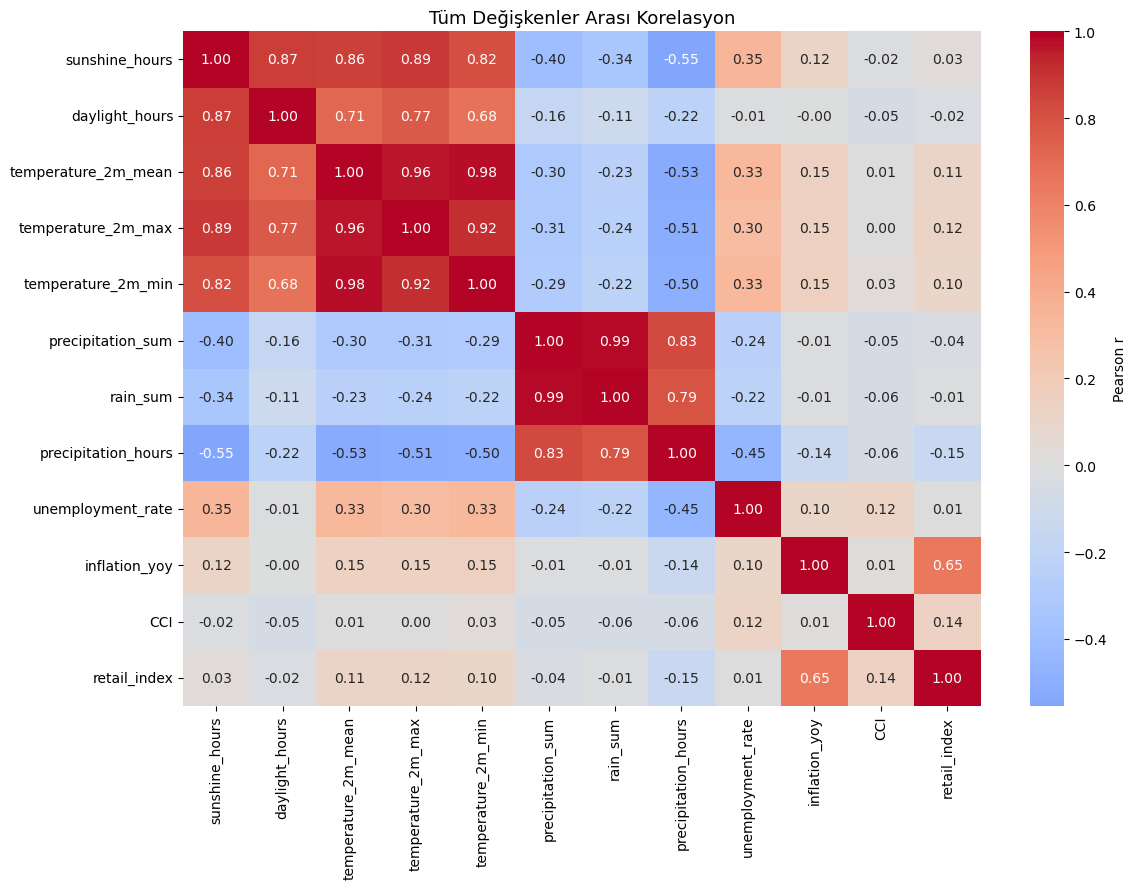

In [5]:
fig, ax = plt.subplots(figsize=(12,9))
corr_features = WEATHER_FEATURES + ['unemployment_rate','inflation_yoy','CCI','retail_index']
sns.heatmap(panel_clean[corr_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Tüm Değişkenler Arası Korelasyon', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ml_01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
scaler = StandardScaler()
X_weather = scaler.fit_transform(panel_clean[WEATHER_FEATURES])

pca = PCA(n_components=8)
X_pca_full = pca.fit_transform(X_weather)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1,9), pca.explained_variance_ratio_, color='steelblue')
axes[0].plot(range(1,9), np.cumsum(pca.explained_variance_ratio_), 'ro-')
axes[0].set_xlabel('Bileşen')
axes[0].set_ylabel('Varyans oranı')
axes[0].set_title('Scree Plot — Hava Değişkenleri PCA')
axes[0].grid(alpha=0.3)

# Loading'ler
loadings = pd.DataFrame(pca.components_[:2].T, 
                        columns=['PC1','PC2'], index=WEATHER_FEATURES)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('PC1 & PC2 Loadings')
plt.tight_layout()
plt.savefig('figures/ml_02_pca_weather.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PC1 + PC2 toplam varyansın {pca.explained_variance_ratio_[:2].sum()*100:.1f}%'ini açıklıyor")

# panel_clean'e PC sütunlarını ekle
panel_clean = panel_clean.copy()
panel_clean['weather_PC1'] = X_pca_full[:, 0]
panel_clean['weather_PC2'] = X_pca_full[:, 1]

# panel_retail'e de aynı PCA dönüşümünü uygula
panel_retail = panel_retail.copy()
X_pca_retail = pca.transform(scaler.transform(panel_retail[WEATHER_FEATURES]))
panel_retail['weather_PC1'] = X_pca_retail[:, 0]
panel_retail['weather_PC2'] = X_pca_retail[:, 1]

print("✅ panel_clean ve panel_retail'e weather_PC1, weather_PC2 eklendi")
print(f"   panel_clean shape: {panel_clean.shape}")
print(f"   panel_retail shape: {panel_retail.shape}")


=== Linear Regression — CCI ===
CV RMSE: 2.361 ± 0.523
CV R²:   0.021 ± 0.021

Katsayılar (büyüklük sırasına göre):
             feature  coefficient  abs_coef
6          month_cos    -1.054387  1.054387
5          month_sin    -0.858602  0.858602
4        covid_dummy    -0.692598  0.692598
0        weather_PC1    -0.423545  0.423545
1        weather_PC2    -0.328151  0.328151
3      inflation_log     0.147339  0.147339
2  unemployment_rate     0.107658  0.107658


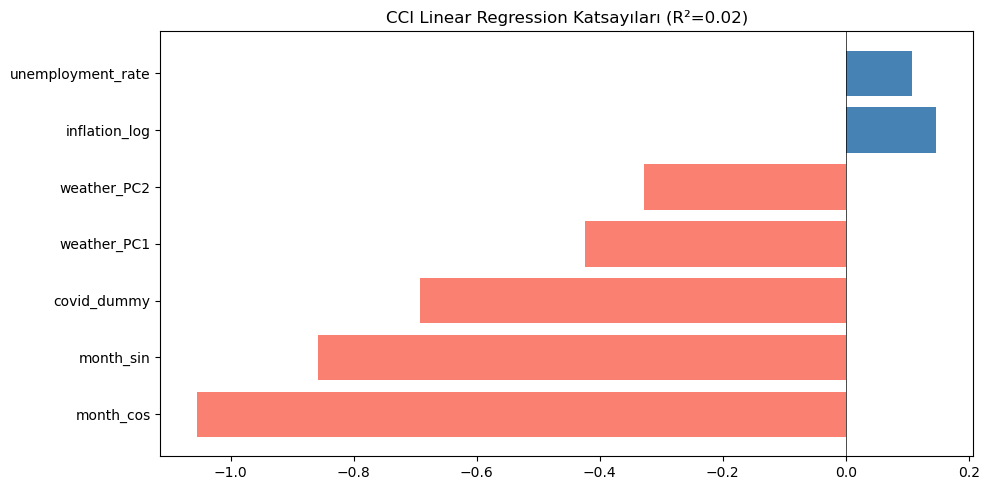

In [33]:
features_for_lr = ['weather_PC1','weather_PC2','unemployment_rate',
                    'inflation_log','covid_dummy','month_sin','month_cos']
X = panel_clean[features_for_lr].values
y = panel_clean['CCI'].values

# 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()
cv_rmse = -cross_val_score(lr, X, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2 = cross_val_score(lr, X, y, cv=kf, scoring='r2')

print(f"=== Linear Regression — CCI ===")
print(f"CV RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"CV R²:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# Tüm veriyle fit + katsayılar
lr.fit(X, y)
coef_df = pd.DataFrame({
    'feature': features_for_lr,
    'coefficient': lr.coef_,
    'abs_coef': np.abs(lr.coef_)
}).sort_values('abs_coef', ascending=False)
print("\nKatsayılar (büyüklük sırasına göre):")
print(coef_df)

# Görselleştir
fig, ax = plt.subplots(figsize=(10,5))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title(f'CCI Linear Regression Katsayıları (R²={cv_r2.mean():.2f})')
plt.tight_layout()

plt.savefig('figures/ml_03_lr_coefficients_cci.png', dpi=150)
plt.show()


In [ ]:
X_r = panel_retail[features_for_lr].values
y_r = panel_retail['retail_index'].values

lr_r = LinearRegression()
cv_rmse_r = -cross_val_score(lr_r, X_r, y_r, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_r = cross_val_score(lr_r, X_r, y_r, cv=kf, scoring='r2')

print(f"=== Linear Regression — Retail Index ===")
print(f"CV RMSE: {cv_rmse_r.mean():.3f} ± {cv_rmse_r.std():.3f}")
print(f"CV R²:   {cv_r2_r.mean():.3f} ± {cv_r2_r.std():.3f}")

lr_r.fit(X_r, y_r)
coef_df_r = pd.DataFrame({
    'feature': features_for_lr,
    'coefficient': lr_r.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print("\nKatsayılar:")
print(coef_df_r)


=== Logistic Regression — CCI yön tahmini ===
Class dağılımı: [241 235]
CV Accuracy: 0.458 ± 0.031
CV AUC:      0.469 ± 0.052


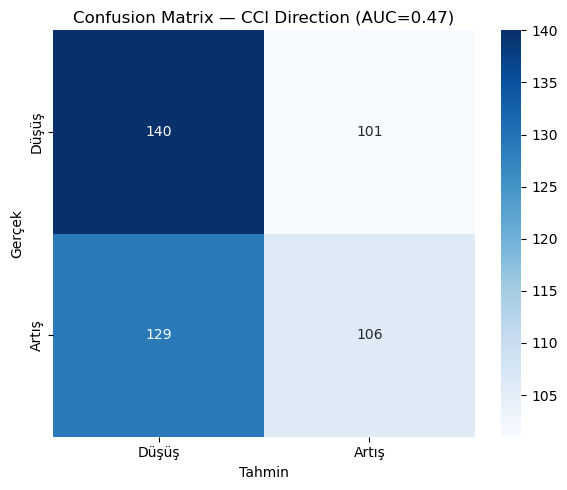

In [35]:
# Binary target: bir sonraki ayın CCI'sı bugünden yüksek mi?
panel_clean = panel_clean.sort_values(['country','year_month']).reset_index(drop=True)
panel_clean['CCI_next'] = panel_clean.groupby('country')['CCI'].shift(-1)
panel_clean['CCI_direction'] = (panel_clean['CCI_next'] > panel_clean['CCI']).astype(int)

mask = panel_clean['CCI_next'].notna()
X_log = panel_clean.loc[mask, features_for_lr].values
y_log = panel_clean.loc[mask, 'CCI_direction'].values

scaler_log = StandardScaler()
X_log_s = scaler_log.fit_transform(X_log)

logreg = LogisticRegression(max_iter=1000, random_state=42)
cv_acc = cross_val_score(logreg, X_log_s, y_log, cv=kf, scoring='accuracy')
cv_auc = cross_val_score(logreg, X_log_s, y_log, cv=kf, scoring='roc_auc')

print(f"=== Logistic Regression — CCI yön tahmini ===")
print(f"Class dağılımı: {np.bincount(y_log)}")
print(f"CV Accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"CV AUC:      {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

logreg.fit(X_log_s, y_log)
y_pred = logreg.predict(X_log_s)
cm = confusion_matrix(y_log, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Düşüş','Artış'], yticklabels=['Düşüş','Artış'])
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
ax.set_title(f'Confusion Matrix — CCI Direction (AUC={cv_auc.mean():.2f})')
plt.tight_layout()
plt.savefig('figures/ml_04_logreg_confusion.png', dpi=150)
plt.show()


=== Random Forest — CCI ===
CV RMSE: 1.968
CV R²:   0.324


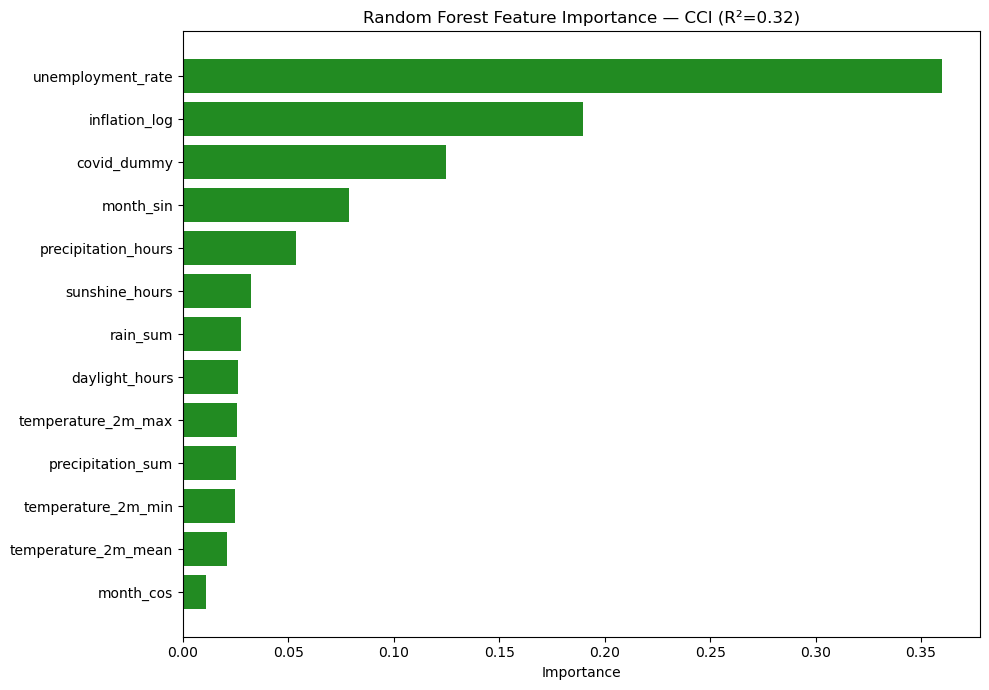

                feature  importance
8     unemployment_rate    0.359968
9         inflation_log    0.189858
10          covid_dummy    0.124863
11            month_sin    0.078548
7   precipitation_hours    0.053703
0        sunshine_hours    0.032473
6              rain_sum    0.027309
1        daylight_hours    0.025947
3    temperature_2m_max    0.025452
5     precipitation_sum    0.025326
4    temperature_2m_min    0.024765
2   temperature_2m_mean    0.020656
12            month_cos    0.011133


In [36]:
rf_features = WEATHER_FEATURES + ['unemployment_rate','inflation_log','covid_dummy',
                                    'month_sin','month_cos']
X_rf = panel_clean[rf_features].values
y_rf = panel_clean['CCI'].values

rf = RandomForestRegressor(n_estimators=200, max_depth=8, 
                            random_state=42, n_jobs=-1)
cv_rmse_rf = -cross_val_score(rf, X_rf, y_rf, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_rf = cross_val_score(rf, X_rf, y_rf, cv=kf, scoring='r2')

print(f"=== Random Forest — CCI ===")
print(f"CV RMSE: {cv_rmse_rf.mean():.3f}")
print(f"CV R²:   {cv_r2_rf.mean():.3f}")

rf.fit(X_rf, y_rf)
imp_df = pd.DataFrame({
    'feature': rf_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10,7))
ax.barh(imp_df['feature'], imp_df['importance'], color='forestgreen')
ax.set_title(f'Random Forest Feature Importance — CCI (R²={cv_r2_rf.mean():.2f})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('figures/ml_05_rf_importance_cci.png', dpi=150)
plt.show()
print(imp_df.iloc[::-1])

=== Random Forest — Retail ===
CV RMSE: 5.510, R²: 0.871

=== Gradient Boosting — CCI ===
CV RMSE: 1.988, R²: 0.312


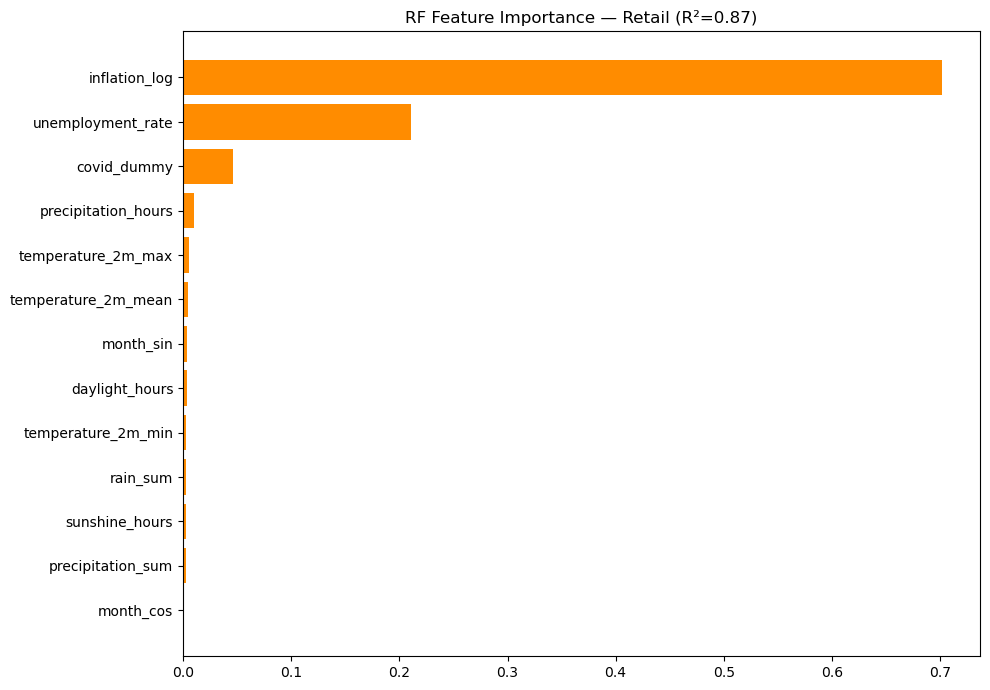

In [37]:
# Retail için RF
X_rf_r = panel_retail[rf_features].values
y_rf_r = panel_retail['retail_index'].values

rf_r = RandomForestRegressor(n_estimators=200, max_depth=8, 
                              random_state=42, n_jobs=-1)
cv_rmse_rf_r = -cross_val_score(rf_r, X_rf_r, y_rf_r, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_rf_r = cross_val_score(rf_r, X_rf_r, y_rf_r, cv=kf, scoring='r2')
print(f"=== Random Forest — Retail ===")
print(f"CV RMSE: {cv_rmse_rf_r.mean():.3f}, R²: {cv_r2_rf_r.mean():.3f}")

rf_r.fit(X_rf_r, y_rf_r)
imp_df_r = pd.DataFrame({
    'feature': rf_features,
    'importance': rf_r.feature_importances_
}).sort_values('importance', ascending=True)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
cv_rmse_gb = -cross_val_score(gb, X_rf, y_rf, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_gb = cross_val_score(gb, X_rf, y_rf, cv=kf, scoring='r2')
print(f"\n=== Gradient Boosting — CCI ===")
print(f"CV RMSE: {cv_rmse_gb.mean():.3f}, R²: {cv_r2_gb.mean():.3f}")

# Retail RF importance grafik
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(imp_df_r['feature'], imp_df_r['importance'], color='darkorange')
ax.set_title(f'RF Feature Importance — Retail (R²={cv_r2_rf_r.mean():.2f})')
plt.tight_layout()
plt.savefig('figures/ml_06_rf_importance_retail.png', dpi=150)
plt.show()


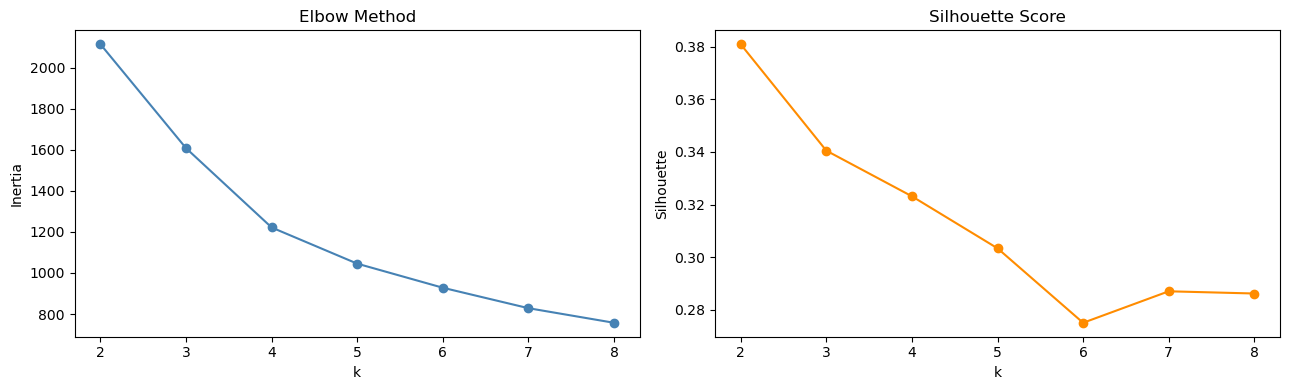

Küme özetleri:
         sunshine_hours  temperature_2m_mean  precipitation_sum    CCI  \
cluster                                                                  
0                208.27                 7.76              43.82  99.92   
1                314.33                16.12              73.29  99.59   
2                372.29                21.97              28.20  99.80   
3                164.47                 7.68              99.81  99.66   

         retail_index  country  
cluster                         
0               99.75       UK  
1               97.37  Germany  
2              100.02    Spain  
3               95.65   Turkey  


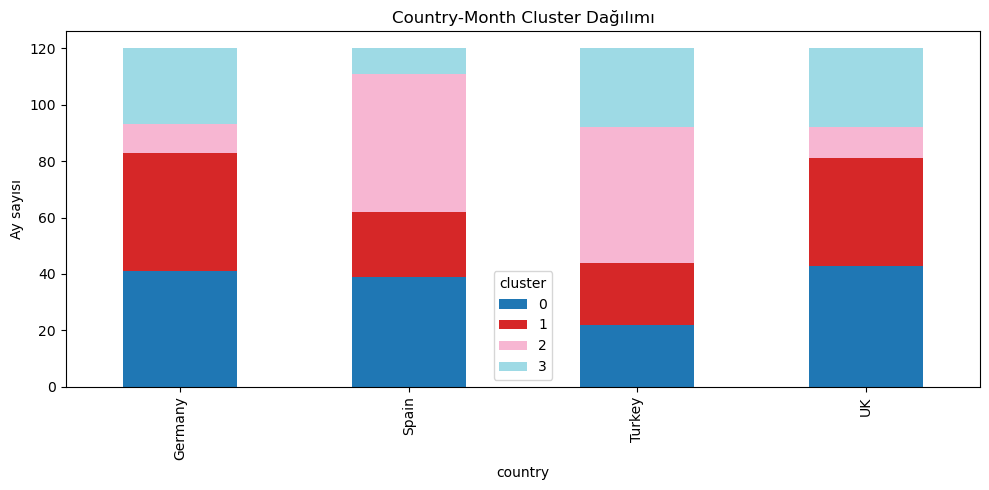

In [38]:
# Hava değişkenlerine göre 480 country-month'u kümele
X_cluster = scaler.fit_transform(panel_clean[WEATHER_FEATURES])

# Optimal k (Elbow + Silhouette)
from sklearn.metrics import silhouette_score
inertias = []
sils = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(2,9), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(range(2,9), sils, 'o-', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('figures/ml_07_kmeans_choice.png', dpi=150)
plt.show()

# k=4 ile fit
km = KMeans(n_clusters=4, random_state=42, n_init=10)
panel_clean['cluster'] = km.fit_predict(X_cluster)

# Her küme için ortalama CCI ve retail
cluster_summary = panel_clean.groupby('cluster').agg({
    'sunshine_hours':'mean',
    'temperature_2m_mean':'mean',
    'precipitation_sum':'mean',
    'CCI':'mean',
    'retail_index':'mean',
    'country':lambda x: x.mode()[0]
}).round(2)
print("Küme özetleri:")
print(cluster_summary)

# Görselleştir: cluster × country dağılımı
fig, ax = plt.subplots(figsize=(10,5))
ct = pd.crosstab(panel_clean['country'], panel_clean['cluster'])
ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Country-Month Cluster Dağılımı')

ax.set_ylabel('Ay sayısı')
plt.tight_layout()
plt.savefig('figures/ml_08_cluster_distribution.png', dpi=150)
plt.show()


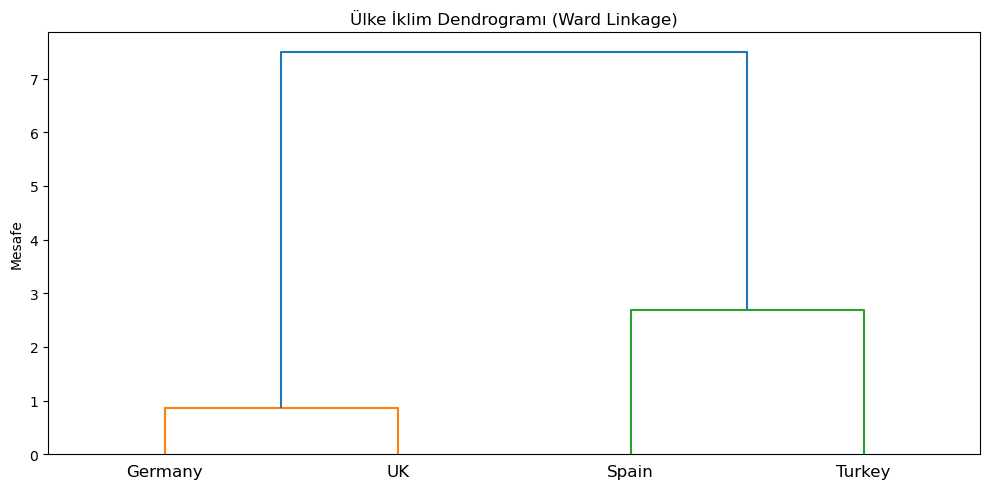

In [39]:
# Her ülke için yıllık ortalama hava profili
country_profile = panel_clean.groupby('country')[WEATHER_FEATURES].mean()
country_scaled = StandardScaler().fit_transform(country_profile)

linkage_matrix = linkage(country_scaled, method='ward')

fig, ax = plt.subplots(figsize=(10,5))
dendrogram(linkage_matrix, labels=country_profile.index.tolist(), ax=ax)
ax.set_title('Ülke İklim Dendrogramı (Ward Linkage)')
ax.set_ylabel('Mesafe')
plt.tight_layout()
plt.savefig('figures/ml_09_hierarchical_dendrogram.png', dpi=150)
plt.show()


In [ ]:
# ============================================================
# ROC EĞRİSİ — Logistic Regression için
# Syllabus: ROC curve (AUC görselleştirmesi)
# ============================================================
from sklearn.metrics import roc_curve, auc

y_proba = logreg.predict_proba(X_log_s)[:, 1]
fpr, tpr, thresholds = roc_curve(y_log, y_proba)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('ROC Curve — CCI Direction Classifier')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_11_roc_curve.png', dpi=150)
plt.show()
print(f"AUC: {roc_auc_val:.3f}")


In [ ]:
# ============================================================
# TEK KARAR AĞACI (max_depth=3, görselleştirilebilir)
# Syllabus: Decision Tree, Gini/Entropy, recursive partitioning
# ============================================================
from sklearn.tree import DecisionTreeRegressor, plot_tree

dt = DecisionTreeRegressor(max_depth=3, random_state=42, criterion='squared_error')
cv_rmse_dt = -cross_val_score(dt, X_rf, y_rf, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_dt = cross_val_score(dt, X_rf, y_rf, cv=kf, scoring='r2')
print(f"Decision Tree (max_depth=3): RMSE={cv_rmse_dt.mean():.3f}, R²={cv_r2_dt.mean():.3f}")

# Tüm veriyle fit + görselleştir
dt.fit(X_rf, y_rf)
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt, feature_names=rf_features, filled=True, rounded=True, 
          fontsize=8, precision=2, ax=ax)
ax.set_title('Decision Tree — CCI tahmini (max_depth=3)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ml_12_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# GRID SEARCH — Random Forest hiperparametre optimizasyonu
# Syllabus: GridSearch ile en iyi hiperparametreler
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
print("GridSearch çalışıyor (~30-60 saniye)...")
grid.fit(X_rf, y_rf)

print(f"\nEn iyi parametreler: {grid.best_params_}")
print(f"En iyi CV RMSE:     {-grid.best_score_:.3f}")
print(f"Default RF RMSE:    {cv_rmse_rf.mean():.3f}")
print(f"İyileşme:           {(cv_rmse_rf.mean() - (-grid.best_score_)):.3f}")

# Tuned model performansı kaydet
cv_rmse_rf_tuned = np.array([-grid.best_score_])
rf_tuned = grid.best_estimator_
cv_r2_rf_tuned = cross_val_score(rf_tuned, X_rf, y_rf, cv=kf, scoring='r2')
print(f"Tuned R²:           {cv_r2_rf_tuned.mean():.3f}")


In [ ]:
# ============================================================
# KNN REGRESYON — CCI tahmini
# Syllabus: KNN, Öklid mesafe, STANDARDIZASYON ŞART
# ============================================================
from sklearn.neighbors import KNeighborsRegressor

# Standardizasyon (KNN için zorunlu — syllabus vurgusu)
scaler_knn = StandardScaler()
X_knn = scaler_knn.fit_transform(panel_clean[rf_features])
y_knn = panel_clean['CCI'].values

# K seçimi (1'den 30'a) — overfitting vs oversmoothing
k_range = range(1, 31)
cv_scores_k = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_knn, y_knn, cv=kf, scoring='r2')
    cv_scores_k.append(scores.mean())

best_k = k_range[int(np.argmax(cv_scores_k))]
print(f"En iyi K: {best_k}, R²={max(cv_scores_k):.3f}")

# K seçim grafiği
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(k_range, cv_scores_k, 'o-', color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', label=f'Optimal K={best_k}')
ax.set_xlabel('K (komşu sayısı)')
ax.set_ylabel('CV R²')
ax.set_title('KNN Regresyon — K seçimi (CCI için)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_13_knn_k_selection.png', dpi=150)
plt.show()

# Final KNN
knn_best = KNeighborsRegressor(n_neighbors=best_k)
cv_rmse_knn = -cross_val_score(knn_best, X_knn, y_knn, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2_knn = cross_val_score(knn_best, X_knn, y_knn, cv=kf, scoring='r2')
print(f"KNN (K={best_k}): RMSE={cv_rmse_knn.mean():.3f}, R²={cv_r2_knn.mean():.3f}")


In [ ]:
# ============================================================
# KNN SINIFLANDIRMA — CCI yön tahmini
# ============================================================
from sklearn.neighbors import KNeighborsClassifier

# X_log_s zaten standardize, kullan
k_range_clf = range(1, 31)
cv_acc_k = []
for k in k_range_clf:
    knnc = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knnc, X_log_s, y_log, cv=kf, scoring='accuracy')
    cv_acc_k.append(scores.mean())

best_k_clf = k_range_clf[int(np.argmax(cv_acc_k))]
print(f"En iyi K (sınıflandırma): {best_k_clf}, Acc={max(cv_acc_k):.3f}")

knnc_best = KNeighborsClassifier(n_neighbors=best_k_clf)
cv_acc_knn = cross_val_score(knnc_best, X_log_s, y_log, cv=kf, scoring='accuracy')
cv_auc_knn = cross_val_score(knnc_best, X_log_s, y_log, cv=kf, scoring='roc_auc')
print(f"KNN sınıflandırma — Acc: {cv_acc_knn.mean():.3f}, AUC: {cv_auc_knn.mean():.3f}")


In [ ]:
# ============================================================
# HIYERARŞIK KÜMELEME — 4 LINKAGE YÖNTEMİ KARŞILAŞTIRMASI
# Syllabus: Single, Complete, Average, Ward linkage
# ============================================================
linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(country_scaled, method=method)
    dendrogram(Z, labels=country_profile.index.tolist(), ax=ax,
               leaf_font_size=11, color_threshold=0)
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12)
    ax.set_ylabel('Mesafe')

plt.suptitle('Hiyerarşik Kümeleme — 4 Linkage Yöntemi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ml_14_linkage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# FİNAL KARŞILAŞTIRMA — TÜM MODELLER
# ============================================================
def _get(name):
    val = globals().get(name)
    if val is None:
        return None
    try:
        return val.mean()
    except AttributeError:
        return val

models_to_report = [
    ('Linear Regression',   'CCI',           'cv_rmse',         'cv_r2'),
    ('Linear Regression',   'Retail',        'cv_rmse_r',       'cv_r2_r'),
    ('Logistic Regression', 'CCI direction', None,              'cv_auc'),
    ('Decision Tree',       'CCI',           'cv_rmse_dt',      'cv_r2_dt'),
    ('Random Forest',       'CCI',           'cv_rmse_rf',      'cv_r2_rf'),
    ('Random Forest (Tuned)','CCI',          'cv_rmse_rf_tuned','cv_r2_rf_tuned'),
    ('Random Forest',       'Retail',        'cv_rmse_rf_r',    'cv_r2_rf_r'),
    ('Gradient Boosting',   'CCI',           'cv_rmse_gb',      'cv_r2_gb'),
    ('KNN Regression',      'CCI',           'cv_rmse_knn',     'cv_r2_knn'),
    ('KNN Classification',  'CCI direction', None,              'cv_auc_knn'),
]

rows = []
for model, target, rmse_var, r2_var in models_to_report:
    rmse_val = _get(rmse_var) if rmse_var else np.nan
    r2_val   = _get(r2_var)
    if r2_val is None:
        continue
    rows.append({
        'model':  model,
        'target': target,
        'RMSE':   rmse_val if rmse_val is not None else np.nan,
        'R²':     r2_val
    })

results = pd.DataFrame(rows)
print("=== Final Model Karşılaştırması ===")
print(results.round(3).to_string(index=False))
results.to_csv('data/model_comparison.csv', index=False)

# Görsel karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_data = results.dropna(subset=['RMSE'])
sns.barplot(data=plot_data, x='model', y='RMSE', hue='target', ax=axes[0])
axes[0].set_title('RMSE Karşılaştırması (düşük = iyi)')
axes[0].tick_params(axis='x', rotation=40)

sns.barplot(data=results, x='model', y='R²', hue='target', ax=axes[1])
axes[1].set_title('R² / AUC Karşılaştırması (yüksek = iyi)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('figures/ml_15_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
